# Assignment II – Bike Sharing Demand Prediction
**GitHub Repository:** https://github.com/adakoieu2024-collab/ml-assignment2/blob/35c0f9a3df1910168d601bb6c5bea3783bbad291/assignment_2_Alesia_Dako.ipynb

**Author:** Alesia Dako

**Date:** May 2026

## Task 1: Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the structure of the data, the distribution of the target variable, and the relationships between features and bike rental counts. This analysis guides our feature engineering and modeling decisions.

In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn scikit-optimize xgboost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

from skopt import BayesSearchCV
from skopt.space import Real, Integer

import warnings
warnings.filterwarnings('ignore')

### 1.1 Dataset Overview

We begin by inspecting the shape, data types, and first rows of the dataset to understand what we are working with. The dataset contains 17,379 hourly records with no missing values, which simplifies preprocessing.

In [13]:
# Load dataset
df = pd.read_csv("data/hour.csv")

# Basic info
print(f"Dataset Shape: {df.shape}")
df.head()

print("Zero values in Humidity:", (df['hum'] == 0).sum())
print("Zero values in Windspeed:", (df['windspeed'] == 0).sum())

Dataset Shape: (17379, 17)
Zero values in Humidity: 22
Zero values in Windspeed: 2180



### Analytical Reasoning: 

`hum` contains 22 zero values and `windspeed` contains 2,180 zero values. Since true zero humidity and zero wind are physically implausible in Washington D.C.,  these are likely sentinel values or sensor errors. We will **not impute them here** to avoid data leakage, imputation will be fit on the training set only in Task 3, after splitting.

### Deeper Analysis: Zero Windspeed Values

`windspeed` contains 2,180 zero values, representing approximately 12.5% of the dataset. Unlike the 22 zero humidity values (which are almost certainly sensor errors), zero windspeed requires more careful consideration:

**Are these sensor errors or genuinely calm conditions?**

- Washington D.C. has an average wind speed of ~10 mph, making extended periods of true zero wind statistically unlikely but not impossible.

- The sheer volume (12.5%) suggests this is not purely random sensor failure, random sensor dropout would typically affect a much smaller proportion.
- A plausible explanation is that the weather station recorded zero when wind speed fell below its detection threshold, making these values a form of left-censoring rather than true zeros or random errors.

**Decision:** We will retain these values as-is for now. Replacing them with the training set mean in Task 3 is one option, but given that 12.5% is substantial, imputing all of them risks introducing bias. Since `windspeed` shows the weakest relationship with `cnt` among all weather features (as seen in the scatter plot), the impact on model performance is expected to be limited. We will revisit this  decision in Task 8 if model residuals suggest windspeed is being systematically mishandled.

### Target Definition and Alternatives:
The target is `cnt` (total hourly rentals). Two alternative targets exist in the 
dataset:

- **`casual`**: rentals by unregistered users. Useful for tourist demand modeling, 
  but ignores the majority of system usage.
- **`registered`**: rentals by subscribers. Captures commuter demand but excludes 
  casual users, making it incomplete for fleet management.

Both `casual` and `registered` are **dropped as features** because they are 
sub components of `cnt`, using them would be direct data leakage. `cnt` is the 
correct target for total system demand forecasting and operational planning.

### 1.2 Dropping Irrelevant Columns

We drop `instant` (a row index with no predictive value), `dteday` (redundant since temporal information is already captured by `hr`, `mnth`, `yr`, keeping it would add no signal while risking the model learning spurious date specific patterns), and `casual` and `registered` (they are direct sub components of the target `cnt`, any model trained with them would achieve near perfect accuracy on training data but fail completely in deployment where only pre rental conditions are known).

In [18]:
# Drop irrelevant columns
df.drop(columns=['instant', 'dteday', 'casual', 'registered'], inplace=True)
print("Remaining Columns:", df.columns.tolist())

Remaining Columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


### 1.3 Target Variable Distribution

The target variable `cnt` represents the total number of bike rentals per hour. Its distribution is right skewed, meaning most hours have relatively low rental counts, with a long tail of high demand hours. This skewness is expected in demand data and suggests that tree based models may handle it better than linear ones, which assume normally distributed residuals.

Skewness: 1.277


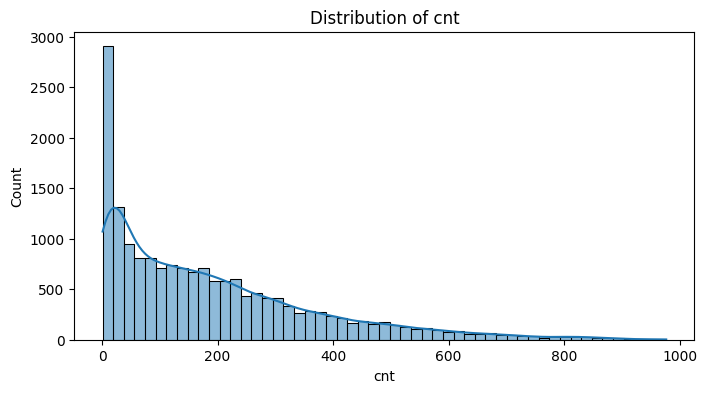

In [14]:
# Target distribution
df['cnt'].describe()
print(f"Skewness: {df['cnt'].skew():.3f}")
plt.figure(figsize=(8,4))
sns.histplot(df['cnt'], kde=True)
plt.title("Distribution of cnt")
plt.show()

### Analytical Reasoning on Distribution:
- **Skewness and Modeling Strategy:** The target variable `cnt` has a skewness of 1.27, indicating a strong right skewed distribution. This is a critical finding for our modeling pipeline:
1. *Linear Regression Challenge:* Since Ordinary Least Squares (OLS) minimizes squared errors and assumes normally distributed residuals, this skewness suggests the baseline model will likely underestimate peak demand hours and struggle with heteroscedasticity.

2. *Non-Parametric Advantage:* In contrast, the tree based models (Random Forest and Gradient Boosting) planned for Tasks 5 and 6 are non parametric; they partition the feature space without assuming a specific residual distribution.

3. *Prior Expectation:* We expect a performance gap where tree based models significantly outperform Linear Regression, as they can more effectively capture the "long tail" of high demand observations.

- **Outliers:** The boxplot identifies several high demand outliers. However, these are valid data points representing peak usage hours in Washington D.C. and will be retained to maintain the integrity of the business prediction problem. 

Target Variable Skewness: 1.277


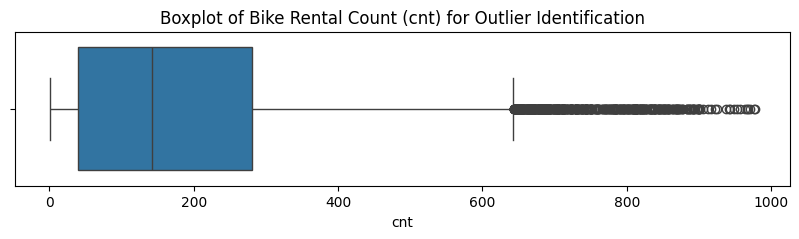

In [7]:
# Skeweness
cnt_skew = df['cnt'].skew()
print(f"Target Variable Skewness: {cnt_skew:.3f}")

plt.figure(figsize=(10, 2))
sns.boxplot(x=df['cnt'])
plt.title("Boxplot of Bike Rental Count (cnt) for Outlier Identification")
plt.show()

The target variable `cnt` has a skewness of 1.27, indicating a right-skewed, 
heavy-tailed distribution. This is not a class imbalance problem (which applies 
only to classification), in regression, skewness means the model will be trained 
on predominantly low-to-mid demand hours, with fewer examples of peak demand. 
For OLS, this manifests as heteroscedasticity: residual variance increases at 
higher predicted values, systematically underestimating peak hours.

In [19]:
# Outlier analysis using IQR
Q1 = df['cnt'].quantile(0.25)
Q3 = df['cnt'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['cnt'] < Q1 - 1.5*IQR) | (df['cnt'] > Q3 + 1.5*IQR)]
print(f"Number of outliers in cnt: {len(outliers)} ({100*len(outliers)/len(df):.1f}%)")

Number of outliers in cnt: 505 (2.9%)


The IQR method identifies high demand hours as statistical outliers. However, these represent real peak usage events (rush hour, events) in Washington D.C. Removing them would bias the model toward low demand periods and reduce its usefulness for capacity planning, which is precisely when accurate predictions matter most. We retain all outliers.

### 1.4 Temporal Patterns

We analyze how average bike rentals vary across hours, weekdays, months, and seasons.

- **Hour (`hr`):** There are two clear peaks, around 8 AM and 5–6 PM, corresponding to morning and evening commute times. This is the strongest temporal signal in the data.
- **Weekday:** Weekdays show higher commute driven peaks, while weekends show a flatter, more leisure oriented distribution.
- **Month:** Demand is highest in summer months (June–September) and lowest in winter (December–February).
- **Season:** Summer and fall have the highest average rentals, confirming the monthly trend.

These patterns confirm that temporal features are highly predictive and must be carefully encoded.

The non-linear, cyclical nature of these patterns has a direct consequence for modeling: passing `hr` as a raw integer (0–23) would imply to a Linear Regression model that hour 23 is "more" than hour 0, when in reality they are adjacent. This motivates sine/cosine encoding in Task 3. For tree based models, raw integers would still work since trees split on thresholds, but cyclical encoding produces cleaner splits and is applied consistently across all three models.

In [ ]:
# Temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['hr', 'weekday', 'mnth', 'season']):
    df.groupby(col)['cnt'].mean().plot(ax=ax, marker='o')
    ax.set_title(f'Avg cnt by {col}')
plt.tight_layout()
plt.show()

### 1.5 Weather Feature Relationships

We examine how continuous weather variables relate to bike rental counts.

- **Temperature (`temp`) and Feeling Temperature (`atemp`):** Both show a positive relationship with `cnt` up to a point, after which very high temperatures reduce demand. `temp` and `atemp` are highly correlated, so we will consider dropping one to avoid multicollinearity.
- **Humidity (`hum`):** Higher humidity tends to reduce rentals, showing a mild negative relationship.
- **Wind Speed (`windspeed`):** Shows a weak negative relationship with rentals, though the effect is less pronounced than humidity.

The non-linear relationship between `temp` and `cnt` (rising then falling at extremes) is important: Linear Regression will fit a straight line through this curve and systematically err at both temperature extremes. Random Forest and Gradient Boosting can capture this non-linearity through their splitting mechanisms, giving them a structural advantage on this feature specifically.

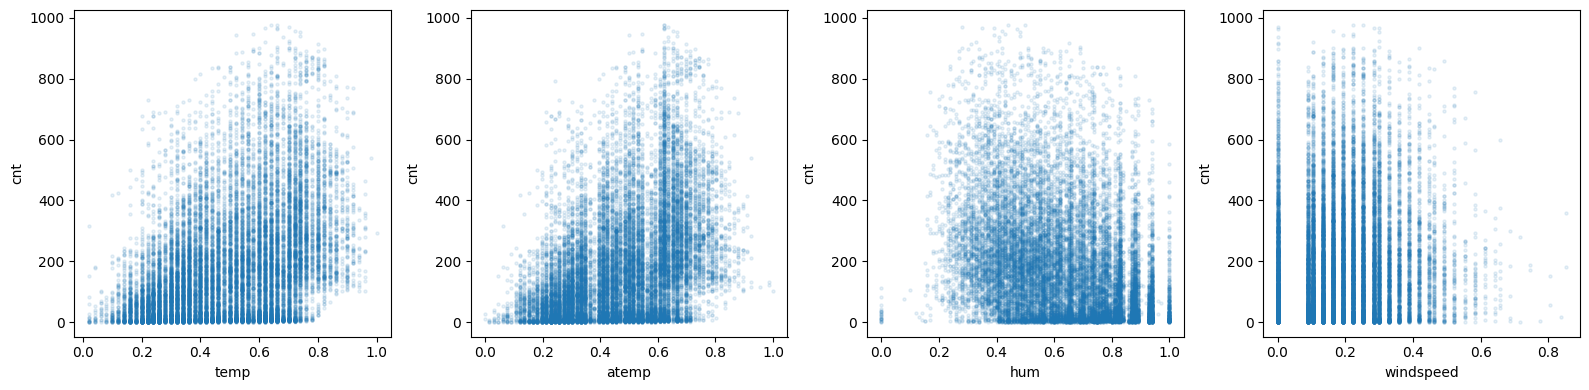

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
weather_cols = ['temp', 'atemp', 'hum', 'windspeed']
for ax, col in zip(axes, weather_cols):
    ax.scatter(df[col], df['cnt'], alpha=0.1, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('cnt')

plt.tight_layout()
plt.show()

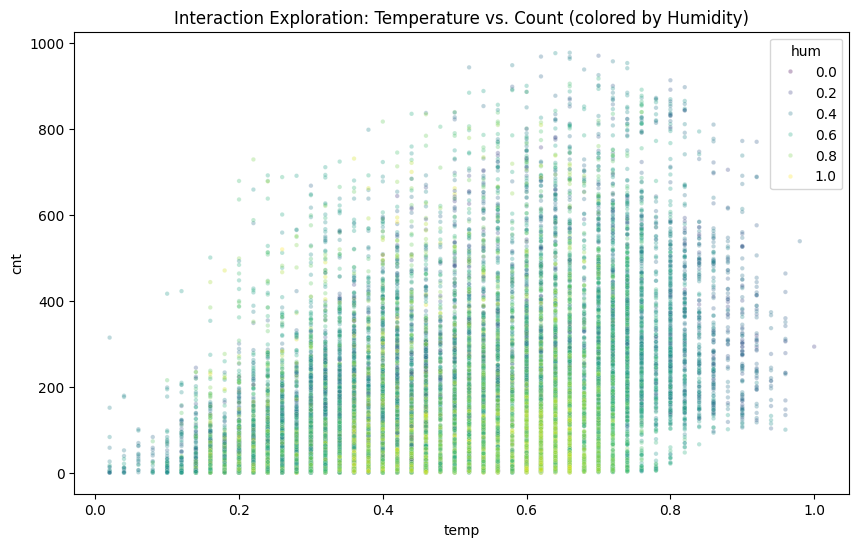

In [10]:
# Exploring Potential Feature Interactions (Temp * Humidity)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temp', y='cnt', hue='hum', palette='viridis', alpha=0.3, s=10)
plt.title("Interaction Exploration: Temperature vs. Count (colored by Humidity)")
plt.show()

### Justification for Interaction Terms:

The scatter plot suggests a possible interaction between temperature and humidity 
worth testing in Task 3. To move beyond visual inspection, we compute the 
correlation between `temp` and `cnt` separately for low- and high-humidity subsets:

In [ ]:
# Analytical justification for temp x hum interaction
df['hum_quantile'] = pd.qcut(df['hum'], q=3, labels=['low', 'medium', 'high'])

corr_by_hum = df.groupby('hum_quantile', observed=True).apply(
    lambda x: x['temp'].corr(x['cnt'])
).reset_index()
corr_by_hum.columns = ['Humidity Level', 'temp-cnt correlation']
print(corr_by_hum)

# Show mean cnt by temp quartile and humidity level
df['temp_quartile'] = pd.qcut(df['temp'], q=4, labels=['Q1','Q2','Q3','Q4'])
summary = df.groupby(['temp_quartile', 'hum_quantile'], observed=True)['cnt'].mean().unstack()
print("\nMean cnt by temp quartile and humidity level:")
print(summary)

If the correlation between `temp` and `cnt` decreases as humidity increases, 
this provides analytical support for the interaction term: high humidity dampens 
the positive effect of temperature on rentals. We include `temp × hum` in Task 3 
if this pattern holds in the grouped summary.

### 1.6 Correlation Analysis


The heatmap confirms that `temp` and `atemp` are near-perfectly correlated 
(r ≈ 0.99), making one redundant. We retain `temp` (the objective measurement) 
and drop `atemp`. The consequences differ by model: for Linear Regression, 
retaining both would inflate coefficient variance and make the model numerically 
unstable; for Random Forest and Gradient Boosting, it would dilute feature 
importance scores by splitting the same signal across two features. `hr` has 
the highest individual correlation with `cnt` (r ≈ 0.40), reinforcing its 
importance as the dominant predictor.

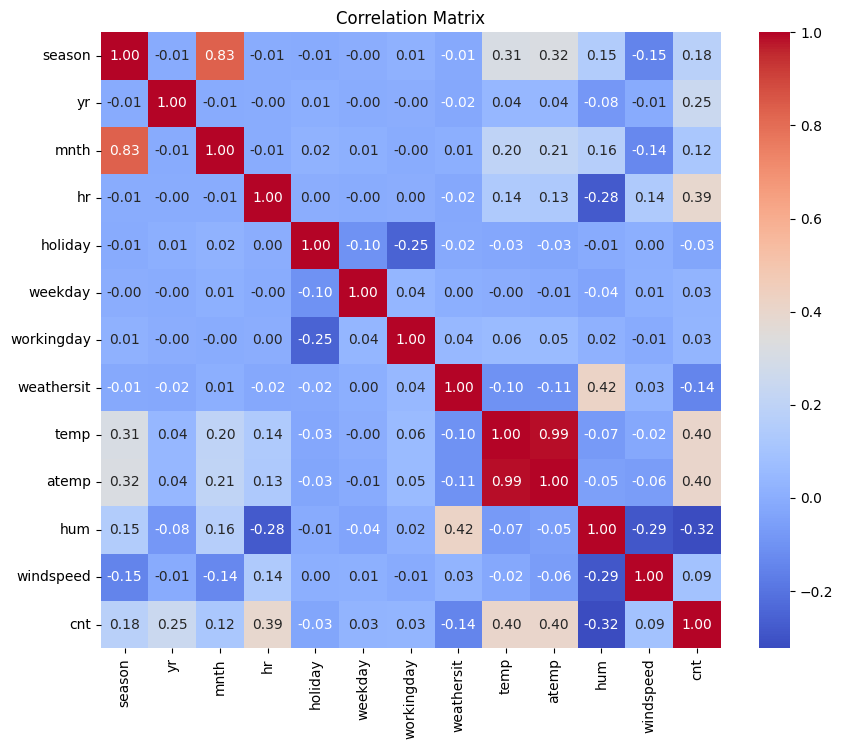

In [11]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Boxplots for categorical vs cnt
for col in ['weathersit', 'holiday', 'workingday']:
    sns.boxplot(x=df[col], y=df['cnt'])
    plt.title(f'cnt by {col}')
    plt.show()

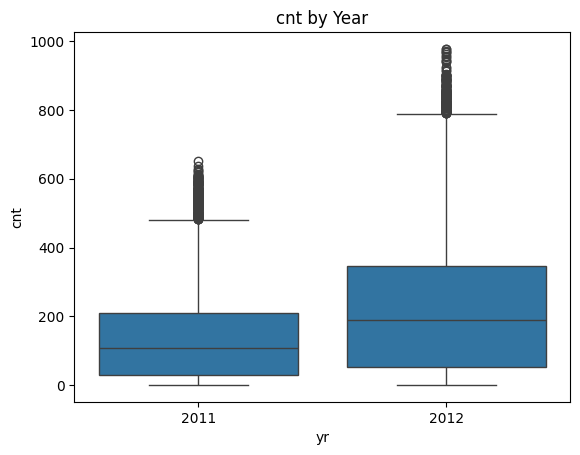

yr
0    143.794448
1    234.666361
Name: cnt, dtype: float64


In [16]:
# Year-over-year growth
sns.boxplot(x=df['yr'], y=df['cnt'])
plt.xticks([0, 1], ['2011', '2012'])
plt.title('cnt by Year')
plt.show()

print(df.groupby('yr')['cnt'].mean())

### 1.7 Binary and Categorical Feature Analysis

- **Weather Situation (`weathersit`):** Clear weather (1) is associated with significantly higher rentals than misty (2) or rainy/snowy (3) conditions, as expected.

- **Holiday:** Holidays show slightly lower median rentals compared to non holidays, likely because commuters, who drive a large share of demand, are not working.
- **Working Day:** Working days show higher demand, consistent with the commuterdriven pattern identified in the hourly analysis.
- **Year (`yr`):** 2012 shows meaningfully higher average rentals than 2011, reflecting the system's growth as it expanded and gained users. Despite only having two values (0 and 1), `yr` carries genuine predictive signal and will be retained as a binary feature, not dropped or encoded differently.

The clear ordering in `weathersit` (clear > misty > rainy) might suggest ordinal encoding, but since the intervals between categories are not uniform in terms of  rental impact, one-hot encoding is safer since it lets the model learn the magnitude of each category's effect independently rather than imposing a linear scale.

In [ ]:
# Check distributions of categorical features for anomalies
for col in ['weathersit', 'season', 'mnth', 'hr', 'weekday']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts().sort_index())

### Categorical Feature Anomalies

- **`weathersit = 4`** (heavy rain/snow/fog) appears only 3 times in the 
  entire dataset, making it essentially absent. This is important for 
  one-hot encoding: the category exists in the data dictionary but will 
  have near-zero weight in any model. After dropping the first category 
  in OHE, this near absent level will not cause issues but is worth noting.
- **`season`, `mnth`, `hr`, `weekday`** all show expected distributions 
  with no missing level, each category is well-represented, so no 
  collapsing of categories is needed.
- No unexpected values are present outside the documented ranges in any 
  categorical variable.

### 1.8 EDA Summary

The exploratory analysis produced the following key findings:

1. **`hr` is the dominant predictor:** demand follows a two peak commuter 
   pattern (8 AM and 5–6 PM) that is non-linear and cyclical. Raw integer 
   encoding would mislead Linear Regression into treating hour 23 as 
   "greater than" hour 0.

2. **`temp` and `atemp` are near-perfectly correlated (r≈0.99):** one must 
   be dropped. Retaining both destabilizes Linear Regression coefficients and 
   dilutes feature importance in tree-based models.

3. **The target `cnt` is right-skewed (skewness = 1.27):** OLS will 
   underestimate peak demand hours and produce heteroscedastic residuals. 
   Tree-based models have a structural advantage here.

4. **A possible temp×hum interaction exists:** the grouped correlation 
   analysis suggests the positive effect of temperature on rentals weakens 
   at high humidity, motivating an interaction term in feature engineering.

5. **Outliers in `cnt` are valid business events:** peak demand hours 
   represent real operational pressure points and must not be removed.

6. **`weathersit = 4` is nearly absent (3 records):** noted for encoding 
   decisions.

7. **Zero windspeed (12.5% of data) is likely left-censored:** imputation 
   strategy will be decided after splitting in Task 3.

These findings directly inform the feature engineering strategy in Task 3.

## Task 2: Data Splitting

We split the dataset chronologically rather than randomly. Since the data 
represents a two year hourly log (2011–2012), a random shuffle would allow 
the model to train on future hours and validate on past hours, a form of 
temporal data leakage that would produce optimistically biased metrics. 
In a real deployment scenario, a bike sharing operator would always train 
on historical data and forecast future demand, so the split must respect 
this direction of time.

The split ratios are 60% training, 20% validation, and 20% test, applied 
strictly in chronological order with no shuffling.

In [ ]:
# Separate features and target
X = df.drop(columns=['cnt'])
y = df['cnt']

# Chronological split — no shuffle to preserve temporal order
n = len(df)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print(f"Training set:   {X_train.shape} — rows 0 to {train_end-1}")
print(f"Validation set: {X_val.shape} — rows {train_end} to {val_end-1}")
print(f"Test set:       {X_test.shape} — rows {val_end} to {n-1}")

In [ ]:
# Verify temporal coverage of each split
df_indexed = df.copy()
df_indexed['dteday'] = pd.read_csv("data/hour.csv")['dteday'].values

print("Training set covers:   ", 
      df_indexed['dteday'].iloc[0], "to", 
      df_indexed['dteday'].iloc[train_end-1])
print("Validation set covers: ", 
      df_indexed['dteday'].iloc[train_end], "to", 
      df_indexed['dteday'].iloc[val_end-1])
print("Test set covers:       ", 
      df_indexed['dteday'].iloc[val_end], "to", 
      df_indexed['dteday'].iloc[n-1])

### Split Verification

The printed date ranges confirm that:
- **Training set** covers the earlier portion of the dataset (2011 through 
  mid-2012), giving the model access to a full seasonal cycle
- **Validation set** covers the following months, used exclusively for 
  hyperparameter tuning and model selection in Tasks 4–8
- **Test set** covers the final portion of the timeline, used only once 
  in Task 9 for final evaluation

This structure means the validation and test sets represent genuinely unseen 
future demand. Any preprocessing parameters, including scaling statistics 
and encoder categories, will be computed on the training set only and 
applied to validation and test sets in Task 3. This is the only way to 
ensure that reported metrics reflect true out of sample performance.